In [ ]:
pip install krippendorff

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import timm
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn.functional as F
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_squared_error, roc_auc_score, average_precision_score
from scipy.stats import pearsonr
import krippendorff
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!unzip -q DL_Assignment1_Dataset.zip

## Data Loader and Augmentation

In [ ]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Different augmentations for expansion
aug_transforms = [
    transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        base_transform
    ]),
    transforms.Compose([
        transforms.RandomRotation(10),
        base_transform
    ]),
    transforms.Compose([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        base_transform
    ]),
    transforms.Compose([
        transforms.GaussianBlur(3, sigma=(0.1, 1.0)),
        base_transform
    ]),
    transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
        base_transform
    ]),
]

# module for loading the dataset and performing augmentations

class AffectNet(Dataset):
    def __init__(self, img_directory, ann_directory, base_transform=None, aug_transforms=None, expand_factor=5):
        self.img_directory = img_directory
        self.ann_directory = ann_directory
        self.base_transform = base_transform
        self.aug_transforms = aug_transforms if aug_transforms else []
        self.expand_factor = expand_factor

        # collect available image indices (based on exp.npy files)
        self.indices = [f.split('_')[0] for f in os.listdir(ann_directory) if f.endswith('_exp.npy')]
        self.indices.sort(key=lambda x: int(x))  # ensure correct ordering

    def __len__(self):
        return len(self.indices) * self.expand_factor

    def __getitem__(self, idx):
        real_idx = idx // self.expand_factor
        aug_idx = idx % self.expand_factor
        img_id = self.indices[real_idx]

        # load image
        img_path = os.path.join(self.img_directory, f"{img_id}.jpg")
        image = Image.open(img_path)

        # load annotations
        expression = int(np.load(os.path.join(self.ann_directory, f"{img_id}_exp.npy")))
        valence = float(np.load(os.path.join(self.ann_directory, f"{img_id}_val.npy")))
        arousal = float(np.load(os.path.join(self.ann_directory, f"{img_id}_aro.npy")))


        # apply augmentation
        if self.aug_transforms and aug_idx < len(self.aug_transforms):
            image = self.aug_transforms[aug_idx](image)
        elif self.base_transform:
            image = self.base_transform(image)

        return image, expression, torch.tensor([valence, arousal], dtype=torch.float)



In [ ]:
# init dataset
train_dataset = AffectNet(
    img_directory="/content/Dataset/Dataset/images",
    ann_directory="/content/Dataset/Dataset/annotations",
    base_transform=base_transform,
    aug_transforms=aug_transforms,
    expand_factor=3
)

print("Original images:", len(train_dataset.indices))
print("Dataset length after augmentation:", len(train_dataset))

# test one sample
img, exp, va = train_dataset[0]
print("Image shape:", img.shape)
print("Expression:", exp, "Valence/Arousal:", va)


Original images: 3999
Dataset length after augmentation: 11997
Image shape: torch.Size([3, 224, 224])
Expression: 0 Valence/Arousal: tensor([-0.1768, -0.0776])


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
imgs, exps, vas = next(iter(train_loader))
print(imgs.shape, exps.shape, vas.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32]) torch.Size([32, 2])


In [ ]:
from sklearn.model_selection import train_test_split

# Grab indices & labels
all_indices = list(range(len(train_dataset)))
all_labels = [train_dataset[i][1] for i in all_indices]  # expression labels

# stratified split
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

# use Subset to create train/val datasets
from torch.utils.data import Subset
train_dataset = Subset(train_dataset, train_idx)
val_dataset = Subset(train_dataset.dataset, val_idx)  # important: point back to base dataset

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 9597
Validation samples: 2400


## Base Model 1: VggFace2Net

In [ ]:
def rmse(y_true, y_pred):
    return torch.sqrt(torch.mean((y_true - y_pred) ** 2)).item()

def concordance_ccc(y_true, y_pred):
    """ Concordance Correlation Coefficient """
    y_true = y_true.detach().cpu().numpy()
    y_pred = y_pred.detach().cpu().numpy()
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + 1e-8)
    return ccc

def krippendorffs_alpha(labels, preds):
    # Krippendorff’s alpha requires a matrix [annotators x items]
    data = np.array([labels, preds])
    return krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')

def correlation(y_true, y_pred):
    y_true, y_pred = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    corr, _ = pearsonr(y_true.flatten(), y_pred.flatten())
    return corr

def sign_agreement(y_true, y_pred):
    y_true, y_pred = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    return np.mean(np.sign(y_true - np.mean(y_true)) == np.sign(y_pred - np.mean(y_pred)))

def compute_metrics(labels, preds, va_true, va_pred, num_classes):
    labels, preds = np.array(labels), np.array(preds)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    kappa = cohen_kappa_score(labels, preds)
    alpha = krippendorffs_alpha(labels, preds)

    probs = np.eye(num_classes)[preds]
    try:
        auc = roc_auc_score(labels, probs, multi_class="ovr")
        pr_auc = average_precision_score(np.eye(num_classes)[labels], probs, average="macro")
    except ValueError:
        auc, pr_auc = np.nan, np.nan

    return {
        "acc": acc, "f1": f1, "kappa": kappa, "alpha": alpha,
        "auc": auc, "pr_auc": pr_auc,
        "rmse": rmse(va_true, va_pred),
        "corr": correlation(va_true, va_pred),
        "sam": sign_agreement(va_true, va_pred),
        "ccc": concordance_ccc(va_true, va_pred)
    }

In [ ]:
class VGGFace2Net(nn.Module):
    def __init__(self, num_classes=8):
        super(VGGFace2Net, self).__init__()
        from torchvision import models
        self.backbone = models.vgg16(pretrained=True)
        self.backbone.classifier = nn.Identity()
        in_features = 25088

        # smaller heads + stronger dropout
        self.exp_head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )
        self.va_head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        feats = self.backbone.features(x)
        feats = feats.view(feats.size(0), -1)
        exp_out = self.exp_head(feats)
        va_out = self.va_head(feats)
        return exp_out, va_out


def train_vgg(model, train_dataset, val_dataset, num_classes=8,
              batch_size=64, lr=1e-4, epochs=30, lambda_reg=1.0,
              device="cuda", patience=5):

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = model.to(device)

    # Freeze backbone initially
    for param in model.backbone.parameters():
        param.requires_grad = False

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    ce_loss = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss()

    history = {k: [] for k in [
        "train_acc","val_acc","train_f1","val_f1","train_kappa","val_kappa",
        "train_alpha","val_alpha","train_auc","val_auc","train_pr_auc","val_pr_auc",
        "train_rmse","val_rmse","train_corr","val_corr","train_sam","val_sam",
        "train_ccc","val_ccc"
    ]}

    best_f1, patience_counter = 0, 0

    for epoch in range(epochs):
        # ---- Phase 1: Train ----
        model.train()
        all_preds, all_labels, va_true, va_pred = [], [], [], []

        for imgs, exps, vas in train_loader:
            imgs, exps, vas = imgs.to(device), exps.to(device), vas.to(device)
            optimizer.zero_grad()

            exp_out, va_out = model(imgs)
            loss = ce_loss(exp_out, exps) + lambda_reg * mse_loss(va_out, vas)
            loss.backward()
            optimizer.step()

            all_preds.extend(torch.argmax(exp_out, dim=1).cpu().numpy())
            all_labels.extend(exps.cpu().numpy())
            va_true.append(vas); va_pred.append(va_out)

        # compute train metrics
        va_true, va_pred = torch.cat(va_true,0), torch.cat(va_pred,0)
        train_metrics = compute_metrics(all_labels, all_preds, va_true, va_pred, num_classes)

        for k,v in train_metrics.items():
            history[f"train_{k}"].append(v)

        # ---- Phase 2: Validation ----
        model.eval()
        val_preds, val_labels, val_va_true, val_va_pred = [], [], [], []
        with torch.no_grad():
            for imgs, exps, vas in val_loader:
                imgs, exps, vas = imgs.to(device), exps.to(device), vas.to(device)
                exp_out, va_out = model(imgs)
                val_preds.extend(torch.argmax(exp_out, dim=1).cpu().numpy())
                val_labels.extend(exps.cpu().numpy())
                val_va_true.append(vas); val_va_pred.append(va_out)

        val_va_true, val_va_pred = torch.cat(val_va_true,0), torch.cat(val_va_pred,0)
        val_metrics = compute_metrics(val_labels, val_preds, val_va_true, val_va_pred, num_classes)

        for k,v in val_metrics.items():
            history[f"val_{k}"].append(v)

        # ---- Print ----
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Acc: {train_metrics['acc']:.3f}, F1: {train_metrics['f1']:.3f}, CCC: {train_metrics['ccc']:.3f} | "
              f"Val Acc: {val_metrics['acc']:.3f}, F1: {val_metrics['f1']:.3f}, CCC: {val_metrics['ccc']:.3f}")

        # LR scheduling
        scheduler.step(val_metrics['f1'])

        # Early stopping
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        # Unfreeze last layers after a few epochs
        if epoch == 3:
            for param in model.backbone.features[-10:].parameters():  # last 2–3 conv blocks
                param.requires_grad = True

    return history


device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def plot_history(history):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(18,12))

    # Accuracy
    plt.subplot(2,3,1)
    plt.plot(epochs, history["train_acc"], 'b-o', label="Train Acc")
    plt.plot(epochs, history["val_acc"], 'r-o', label="Val Acc")
    plt.title("Accuracy"); plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

    # F1-score
    plt.subplot(2,3,2)
    plt.plot(epochs, history["train_f1"], 'b-o', label="Train F1")
    plt.plot(epochs, history["val_f1"], 'r-o', label="Val F1")
    plt.title("F1-score"); plt.xlabel("Epochs"); plt.ylabel("F1"); plt.legend()

    # Cohen Kappa
    plt.subplot(2,3,3)
    plt.plot(epochs, history["train_kappa"], 'b-o', label="Train Kappa")
    plt.plot(epochs, history["val_kappa"], 'r-o', label="Val Kappa")
    plt.title("Cohen Kappa"); plt.xlabel("Epochs"); plt.ylabel("Kappa"); plt.legend()

    # RMSE
    plt.subplot(2,3,4)
    plt.plot(epochs, history["train_rmse"], 'b-o', label="Train RMSE")
    plt.plot(epochs, history["val_rmse"], 'r-o', label="Val RMSE")
    plt.title("RMSE (Valence/Arousal)"); plt.xlabel("Epochs"); plt.ylabel("RMSE"); plt.legend()

    # CCC
    plt.subplot(2,3,5)
    plt.plot(epochs, history["train_ccc"], 'b-o', label="Train CCC")
    plt.plot(epochs, history["val_ccc"], 'r-o', label="Val CCC")
    plt.title("CCC (Valence/Arousal)"); plt.xlabel("Epochs"); plt.ylabel("CCC"); plt.legend()

    plt.tight_layout()
    plt.show()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 89.6MB/s]


Epoch 1/10 | Train Acc: 0.258, F1: 0.255, CCC: 0.479 | Val Acc: 0.366, F1: 0.361, CCC: 0.537
Epoch 2/10 | Train Acc: 0.419, F1: 0.416, CCC: 0.594 | Val Acc: 0.425, F1: 0.413, CCC: 0.601
Epoch 3/10 | Train Acc: 0.528, F1: 0.526, CCC: 0.654 | Val Acc: 0.469, F1: 0.460, CCC: 0.578
Epoch 4/10 | Train Acc: 0.605, F1: 0.604, CCC: 0.704 | Val Acc: 0.499, F1: 0.491, CCC: 0.609
Epoch 5/10 | Train Acc: 0.682, F1: 0.682, CCC: 0.726 | Val Acc: 0.605, F1: 0.602, CCC: 0.661
Epoch 6/10 | Train Acc: 0.810, F1: 0.810, CCC: 0.764 | Val Acc: 0.670, F1: 0.668, CCC: 0.722
Epoch 7/10 | Train Acc: 0.891, F1: 0.891, CCC: 0.801 | Val Acc: 0.690, F1: 0.693, CCC: 0.733
Epoch 8/10 | Train Acc: 0.925, F1: 0.925, CCC: 0.812 | Val Acc: 0.742, F1: 0.742, CCC: 0.737
Epoch 9/10 | Train Acc: 0.954, F1: 0.954, CCC: 0.835 | Val Acc: 0.758, F1: 0.757, CCC: 0.768
Epoch 10/10 | Train Acc: 0.964, F1: 0.964, CCC: 0.845 | Val Acc: 0.779, F1: 0.779, CCC: 0.764


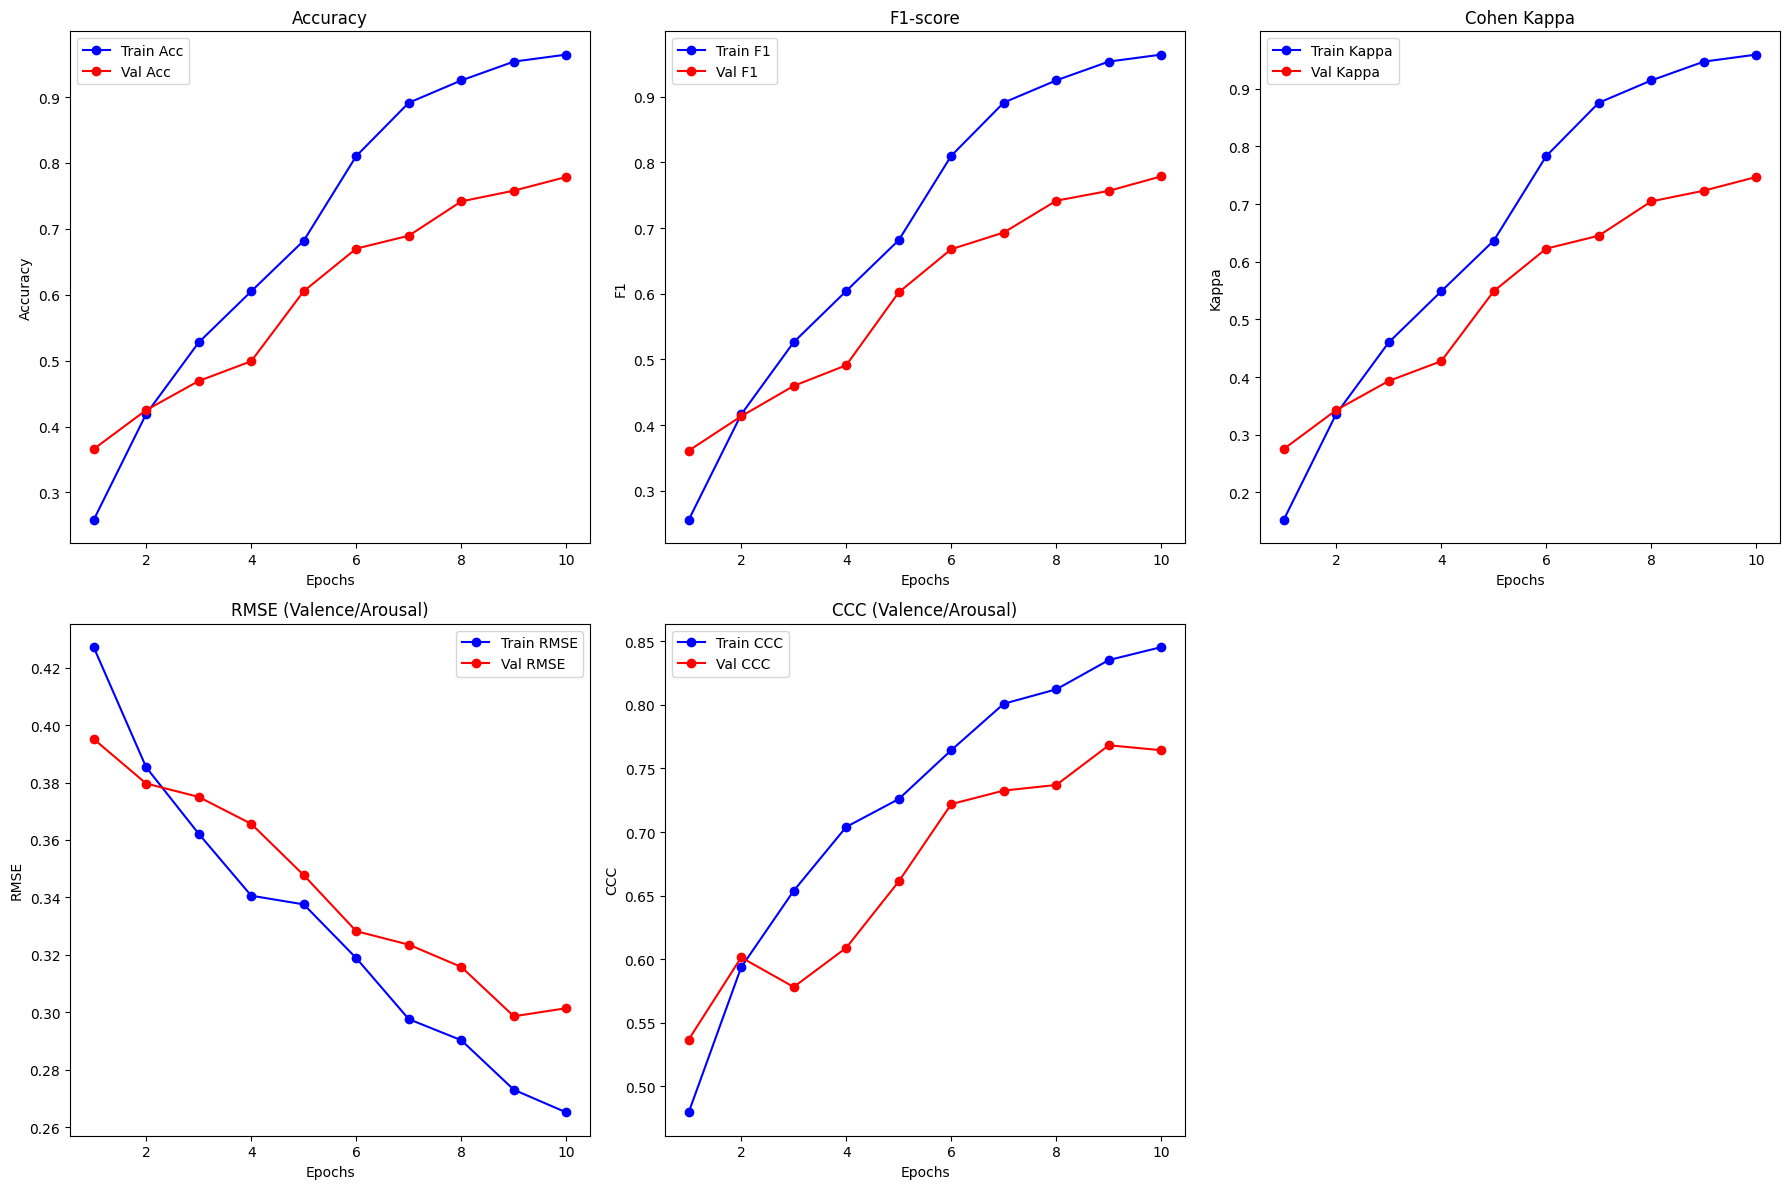

In [ ]:
model = VGGFace2Net(num_classes=8)
history = train_vgg(model, train_dataset, val_dataset, epochs=10, device=device)
plot_history(history)

In [ ]:
print("\nFinal Metrics For Report:")
last_epoch = len(history["val_acc"]) - 1
for k in history.keys():
    final_value = history[k][last_epoch]
    print(f"{k}: {final_value:.4f}")


Final Metrics For Report:
train_acc: 0.9644
val_acc: 0.7788
train_f1: 0.9644
val_f1: 0.7789
train_kappa: 0.9593
val_kappa: 0.7471
train_alpha: 0.9593
val_alpha: 0.7471
train_auc: 0.9796
val_auc: 0.8736
train_pr_auc: 0.9345
val_pr_auc: 0.6363
train_rmse: 0.2651
val_rmse: 0.3014
train_corr: 0.8520
val_corr: 0.8104
train_sam: 0.8563
val_sam: 0.8073
train_ccc: 0.8454
val_ccc: 0.7643


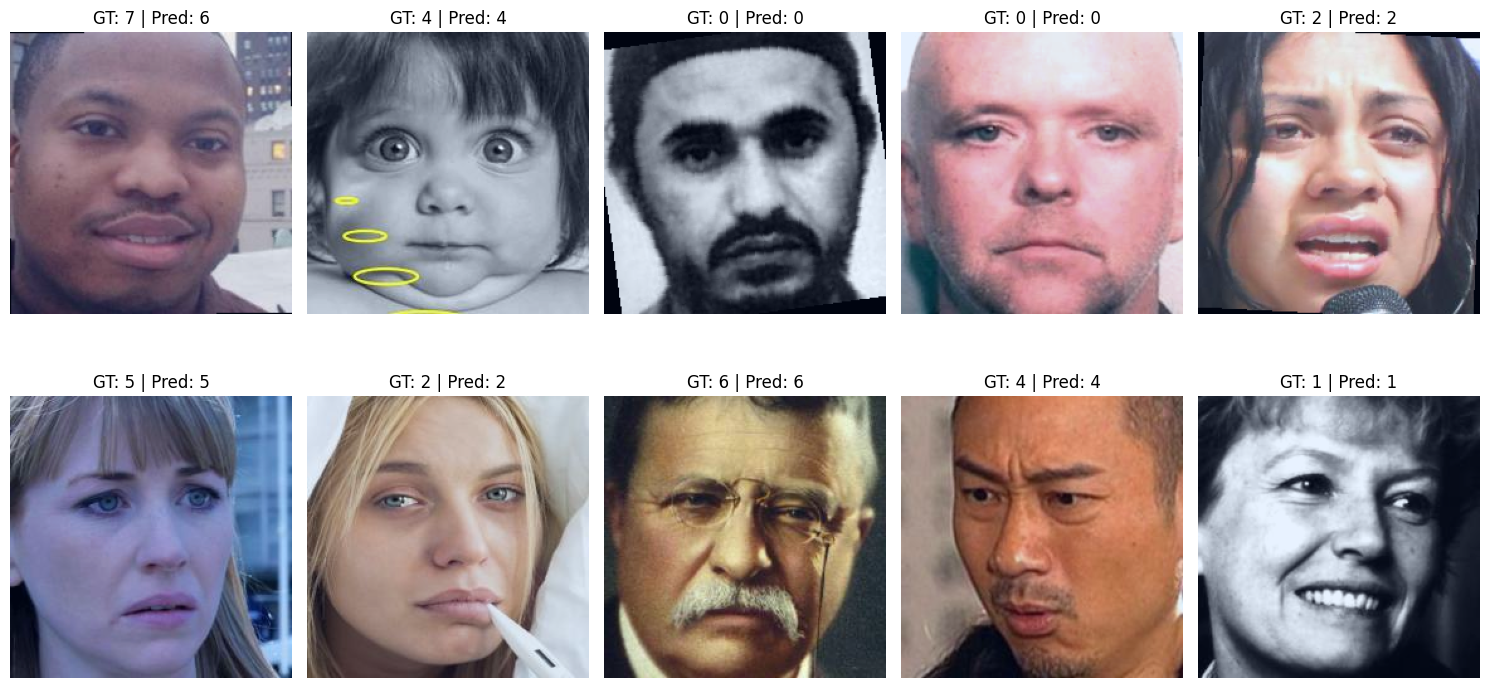

In [ ]:
def show_random_predictions(model, dataset, device, num_images=10):
    model.eval()
    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(indices):
        img, label, va = dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)  # add batch dim

        with torch.no_grad():
            exp_out, va_out = model(img_tensor)
            pred_label = torch.argmax(exp_out, dim=1).item()

        # convert back to numpy for display
        img_disp = img.permute(1, 2, 0).cpu().numpy()
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())  # normalize to [0,1]

        plt.subplot(2, 5, i+1)
        plt.imshow(img_disp)
        plt.axis("off")
        plt.title(f"GT: {label} | Pred: {pred_label}")

    plt.tight_layout()
    plt.show()


# Call the function
show_random_predictions(model, val_dataset, device, num_images=10)

## Base Model 2: SE-ResNet

In [45]:
def rmse(y_true, y_pred):
    return torch.sqrt(torch.mean((y_true - y_pred) ** 2)).item()

def concordance_ccc(y_true, y_pred):
    y_true, y_pred = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + 1e-8)

def krippendorffs_alpha(labels, preds):
    data = np.array([labels, preds])
    return krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')

def correlation(y_true, y_pred):
    y_true, y_pred = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    corr, _ = pearsonr(y_true.flatten(), y_pred.flatten())
    return corr

def sign_agreement(y_true, y_pred):
    y_true, y_pred = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    return np.mean(np.sign(y_true - np.mean(y_true)) == np.sign(y_pred - np.mean(y_pred)))


def compute_metrics(y_true_class, y_pred_class, y_true_reg, y_pred_reg):
    """
    Compute classification + regression metrics for emotion recognition.
    y_true_class, y_pred_class: classification labels (numpy or list)
    y_true_reg, y_pred_reg: regression tensors (valence/arousal)
    """
    # Ensure numpy arrays
    y_true_class = np.array(y_true_class)
    y_pred_class = np.array(y_pred_class)

    # Classification metrics
    acc = accuracy_score(y_true_class, y_pred_class)
    f1 = f1_score(y_true_class, y_pred_class, average="macro")
    kappa = cohen_kappa_score(y_true_class, y_pred_class)

    try:
        auc = roc_auc_score(y_true_class,
                            np.eye(len(np.unique(y_true_class)))[y_pred_class],
                            multi_class="ovr")
    except Exception:
        auc = np.nan
    try:
        pr_auc = average_precision_score(y_true_class,
                                         np.eye(len(np.unique(y_true_class)))[y_pred_class],
                                         average="macro")
    except Exception:
        pr_auc = np.nan

    # Regression metrics (valence-arousal)
    rmse_val = rmse(y_true_reg, y_pred_reg)
    corr_val = correlation(y_true_reg, y_pred_reg)
    ccc_val = concordance_ccc(y_true_reg, y_pred_reg)
    sam_val = sign_agreement(y_true_reg, y_pred_reg)

    return {
        "acc": acc,
        "f1": f1,
        "kappa": kappa,
        "auc": auc,
        "pr_auc": pr_auc,
        "rmse": rmse_val,
        "corr": corr_val,
        "ccc": ccc_val,
        "sam": sam_val
    }

In [46]:
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

class SEBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, reduction=16):
        super(SEBasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SELayer(out_channels, reduction)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

class SEResNet(nn.Module):
    def __init__(self, num_classes=8):
        super(SEResNet, self).__init__()
        base = timm.create_model("seresnet50", pretrained=False, num_classes=0)  # remove classifier
        self.backbone = base
        self.exp_head = nn.Linear(base.num_features, num_classes)  # classification head
        self.va_head = nn.Linear(base.num_features, 2)  # regression head

    def forward(self, x):
        feats = self.backbone(x)
        exp_out = self.exp_head(feats)
        va_out = self.va_head(feats)
        return exp_out, va_out


In [47]:
class Trainer:
    def __init__(self, model, train_loader, val_loader, device="cuda", lr=1e-4):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device

        self.ce_loss = nn.CrossEntropyLoss()
        self.mse_loss = nn.MSELoss()
        self.optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

        # History storage
        self.history = {k: [] for k in [
            "train_loss", "val_loss",
            "train_acc","val_acc","train_f1","val_f1","train_kappa","val_kappa",
            "train_alpha","val_alpha","train_auc","val_auc","train_pr_auc","val_pr_auc",
            "train_rmse","val_rmse","train_corr","val_corr","train_sam","val_sam",
            "train_ccc","val_ccc"
        ]}

    def train(self, epochs=10):
        for epoch in range(epochs):
            # ---- Training ----
            self.model.train()
            all_preds, all_labels, va_true, va_pred = [], [], [], []
            train_loss = 0

            for imgs, labels, va in self.train_loader:
                imgs, labels, va = imgs.to(self.device), labels.to(self.device), va.to(self.device)

                self.optimizer.zero_grad()
                exp_out, va_out = self.model(imgs)

                loss_class = self.ce_loss(exp_out, labels)
                loss_reg = self.mse_loss(va_out, va)
                loss = loss_class + loss_reg

                loss.backward()
                self.optimizer.step()

                train_loss += loss.item() * imgs.size(0)
                all_preds.extend(torch.argmax(exp_out, dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                va_true.append(va); va_pred.append(va_out)

            va_true, va_pred = torch.cat(va_true,0), torch.cat(va_pred,0)
            train_metrics = compute_metrics(all_labels, all_preds, va_true, va_pred)

            # ---- Validation ----
            self.model.eval()
            val_preds, val_labels, val_va_true, val_va_pred = [], [], [], []
            val_loss = 0
            with torch.no_grad():
                for imgs, labels, va in self.val_loader:
                    imgs, labels, va = imgs.to(self.device), labels.to(self.device), va.to(self.device)
                    exp_out, va_out = self.model(imgs)

                    loss_class = self.ce_loss(exp_out, labels)
                    loss_reg = self.mse_loss(va_out, va)
                    loss = loss_class + loss_reg
                    val_loss += loss.item() * imgs.size(0)

                    val_preds.extend(torch.argmax(exp_out, dim=1).cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())
                    val_va_true.append(va); val_va_pred.append(va_out)

            val_va_true, val_va_pred = torch.cat(val_va_true,0), torch.cat(val_va_pred,0)
            val_metrics = compute_metrics(val_labels, val_preds, val_va_true, val_va_pred)

            # ---- Store + Print ----
            for k,v in train_metrics.items():
                self.history[f"train_{k}"].append(v)
            for k,v in val_metrics.items():
                self.history[f"val_{k}"].append(v)

            self.history["train_loss"].append(train_loss / len(self.train_loader.dataset))
            self.history["val_loss"].append(val_loss / len(self.val_loader.dataset))

            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Acc: {train_metrics['acc']:.3f}, F1: {train_metrics['f1']:.3f}, CCC: {train_metrics['ccc']:.3f} | "
                  f"Val Acc: {val_metrics['acc']:.3f}, F1: {val_metrics['f1']:.3f}, CCC: {val_metrics['ccc']:.3f}")

    def plot_history(self):
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.plot(self.history["train_loss"], label="Train Loss")
        plt.plot(self.history["val_loss"], label="Val Loss")
        plt.legend()
        plt.title("Loss over epochs")

        plt.subplot(1,2,2)
        plt.plot(self.history["train_acc"], label="Train Acc")
        plt.plot(self.history["val_acc"], label="Val Acc")
        plt.legend()
        plt.title("Accuracy over epochs")
        plt.show()


In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
# Instantiate SE-ResNet model
seresnet_model = SEResNet(num_classes=8)

trainer = Trainer(seresnet_model, train_loader, val_loader, device=device)

# Train SE-ResNet for 10 epochs
trainer.train(epochs=10)

Epoch 1/10 | Train Acc: 0.170, F1: 0.167, CCC: 0.444 | Val Acc: 0.155, F1: 0.125, CCC: 0.468
Epoch 2/10 | Train Acc: 0.196, F1: 0.194, CCC: 0.471 | Val Acc: 0.180, F1: 0.157, CCC: 0.336
Epoch 3/10 | Train Acc: 0.213, F1: 0.211, CCC: 0.476 | Val Acc: 0.191, F1: 0.155, CCC: 0.437
Epoch 4/10 | Train Acc: 0.224, F1: 0.222, CCC: 0.488 | Val Acc: 0.199, F1: 0.187, CCC: 0.495
Epoch 5/10 | Train Acc: 0.244, F1: 0.241, CCC: 0.502 | Val Acc: 0.239, F1: 0.205, CCC: 0.503
Epoch 6/10 | Train Acc: 0.298, F1: 0.292, CCC: 0.539 | Val Acc: 0.260, F1: 0.221, CCC: 0.482
Epoch 7/10 | Train Acc: 0.360, F1: 0.354, CCC: 0.583 | Val Acc: 0.318, F1: 0.303, CCC: 0.575
Epoch 8/10 | Train Acc: 0.425, F1: 0.420, CCC: 0.633 | Val Acc: 0.323, F1: 0.288, CCC: 0.409
Epoch 9/10 | Train Acc: 0.498, F1: 0.494, CCC: 0.691 | Val Acc: 0.364, F1: 0.324, CCC: 0.652
Epoch 10/10 | Train Acc: 0.589, F1: 0.587, CCC: 0.747 | Val Acc: 0.418, F1: 0.407, CCC: 0.554


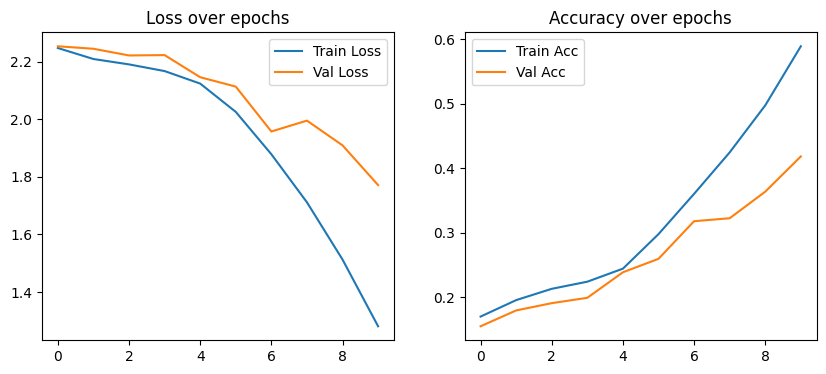

In [49]:
trainer.plot_history()

## Ignore ResNet

In [44]:
def rmse(y_true, y_pred):
    return torch.sqrt(torch.mean((y_true - y_pred) ** 2)).item()

def concordance_ccc(y_true, y_pred):
    y_true, y_pred = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + 1e-8)

def krippendorffs_alpha(labels, preds):
    data = np.array([labels, preds])
    return krippendorff.alpha(reliability_data=data, level_of_measurement='nominal')

def correlation(y_true, y_pred):
    y_true, y_pred = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    corr, _ = pearsonr(y_true.flatten(), y_pred.flatten())
    return corr

def sign_agreement(y_true, y_pred):
    y_true, y_pred = y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy()
    return np.mean(np.sign(y_true - np.mean(y_true)) == np.sign(y_pred - np.mean(y_pred)))


Epoch 1/10 | Train Loss: 2.1210, Acc: 0.147, F1: 0.147 | Val Loss: 2.0722, Acc: 0.165, F1: 0.119
Epoch 2/10 | Train Loss: 2.0523, Acc: 0.175, F1: 0.172 | Val Loss: 2.0407, Acc: 0.194, F1: 0.144
Epoch 3/10 | Train Loss: 1.9432, Acc: 0.242, F1: 0.239 | Val Loss: 1.9696, Acc: 0.265, F1: 0.249
Epoch 4/10 | Train Loss: 1.7923, Acc: 0.314, F1: 0.308 | Val Loss: 1.7586, Acc: 0.347, F1: 0.333
Epoch 5/10 | Train Loss: 1.6343, Acc: 0.378, F1: 0.373 | Val Loss: 1.7638, Acc: 0.324, F1: 0.307
Epoch 6/10 | Train Loss: 1.5071, Acc: 0.429, F1: 0.425 | Val Loss: 1.5586, Acc: 0.404, F1: 0.395
Epoch 7/10 | Train Loss: 1.3829, Acc: 0.481, F1: 0.478 | Val Loss: 1.6262, Acc: 0.390, F1: 0.349
Epoch 8/10 | Train Loss: 1.2424, Acc: 0.535, F1: 0.534 | Val Loss: 1.7533, Acc: 0.423, F1: 0.398
Epoch 9/10 | Train Loss: 1.0782, Acc: 0.602, F1: 0.600 | Val Loss: 1.5464, Acc: 0.475, F1: 0.447
Epoch 10/10 | Train Loss: 0.8782, Acc: 0.680, F1: 0.679 | Val Loss: 1.4912, Acc: 0.484, F1: 0.479


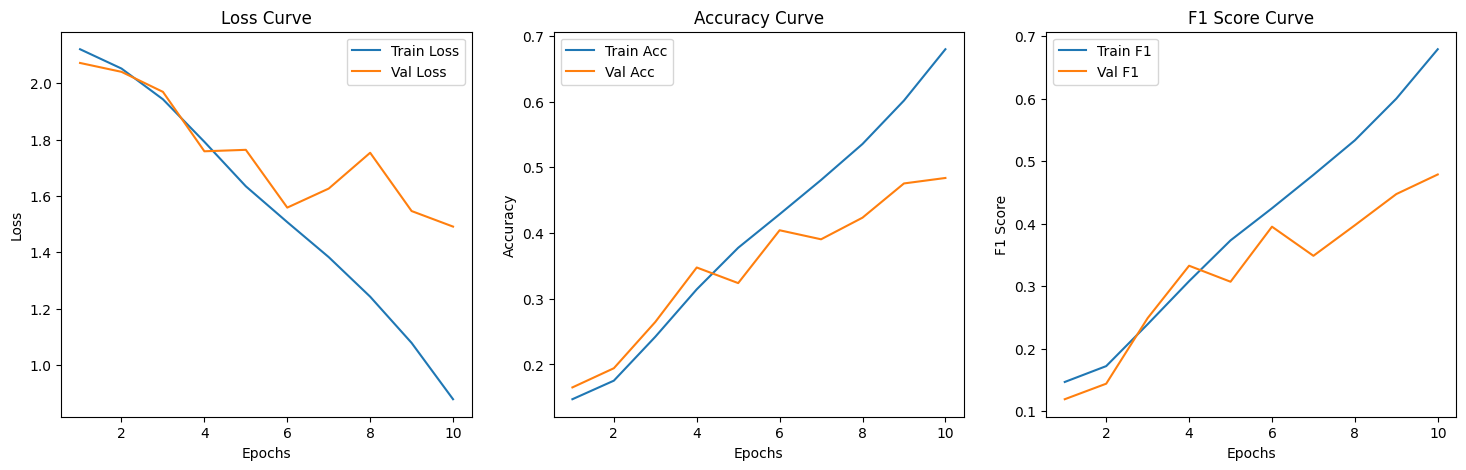

In [43]:
class BasicResNet(nn.Module):
    def __init__(self, num_classes=8):
        super(BasicResNet, self).__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


def train_model(model, train_loader, val_loader, device, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        train_preds, train_labels = [], []

        for batch in train_loader:
            if isinstance(batch, (list, tuple)):
                x, y = batch[0], batch[1]
            else:
                raise ValueError("Unexpected batch format")

            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == y).sum().item()
            train_total += y.size(0)

            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(y.cpu().numpy())

        train_acc = train_correct / train_total
        train_f1 = f1_score(train_labels, train_preds, average="weighted")
        history["train_loss"].append(train_loss / train_total)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)

        # ---- Validation ----
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, (list, tuple)):
                    x, y = batch[0], batch[1]
                else:
                    raise ValueError("Unexpected batch format")

                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)

                val_loss += loss.item() * x.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y).sum().item()
                val_total += y.size(0)

                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(y.cpu().numpy())

        val_acc = val_correct / val_total
        val_f1 = f1_score(val_labels, val_preds, average="weighted")
        history["val_loss"].append(val_loss / val_total)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.4f}, Acc: {train_acc:.3f}, F1: {train_f1:.3f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f}, Acc: {val_acc:.3f}, F1: {val_f1:.3f}")

    return history


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 5))
    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epochs"); plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    # F1 Score
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_f1"], label="Train F1")
    plt.plot(epochs, history["val_f1"], label="Val F1")
    plt.xlabel("Epochs"); plt.ylabel("F1 Score")
    plt.title("F1 Score Curve")
    plt.legend()

    plt.show()

def evaluate_metrics(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            x, y = batch[0].to(device), batch[1].to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred, average="weighted"),
        "Kappa": cohen_kappa_score(y_true, y_pred),
        "Alpha": krippendorffs_alpha(y_true, y_pred),
        "AUC": roc_auc_score(y_true, F.one_hot(torch.tensor(y_pred), num_classes=8), multi_class="ovr"),
        "PR-AUC": average_precision_score(y_true, y_pred, average="weighted"),
        "RMSE": rmse(torch.tensor(y_true), torch.tensor(y_pred)),
        "Correlation": correlation(torch.tensor(y_true), torch.tensor(y_pred)),
        "Sign Agreement": sign_agreement(torch.tensor(y_true), torch.tensor(y_pred)),
        "CCC": concordance_ccc(torch.tensor(y_true), torch.tensor(y_pred)),
    }
    return metrics


if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = BasicResNet(num_classes=8).to(device)

    history = train_model(model, train_loader, val_loader, device, epochs=10, lr=1e-3)
    plot_history(history)

    print("\nFinal Evaluation Metrics:")
    results = evaluate_metrics(model, val_loader, device)
    for k, v in results.items():
        print(f"{k}: {v:.4f}")


## Custom CNN

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()

        # Conv Blocks
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 512, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(512)

        self.conv4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)   ### increase dropout a bit

        # Shared Fully Connected Layers
        self.fc1 = nn.Linear(512 * 14 * 14, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 512)
        self.bn_fc2 = nn.BatchNorm1d(512)

        # Two heads: Classification + Regression
        self.fc_class = nn.Linear(512, num_classes)   # expression classification
        self.fc_reg = nn.Linear(512, 2)               # valence & arousal regression

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)

        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)

        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.dropout(x)

        x = torch.flatten(x, 1)

        x = self.dropout(F.relu(self.bn_fc1(self.fc1(x))))
        x = self.dropout(F.relu(self.bn_fc2(self.fc2(x))))

        class_out = self.fc_class(x)
        reg_out = self.fc_reg(x)
        return class_out, reg_out


def compute_classification_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    kappa = cohen_kappa_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr") if y_prob is not None else np.nan
    pr_auc = average_precision_score(
        np.eye(len(np.unique(y_true)))[y_true], y_prob, average="weighted"
    ) if y_prob is not None else np.nan
    ccc = np.nan  # classification doesn’t use CCC, placeholder
    return acc, f1, kappa, auc, pr_auc, ccc


def concordance_cc(y_true, y_pred):
    """Concordance correlation coefficient for regression."""
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2)


def compute_regression_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    corr, _ = pearsonr(y_true.flatten(), y_pred.flatten())
    ccc = concordance_cc(y_true.flatten(), y_pred.flatten())
    return mse, rmse, corr, ccc


def train_model(model, train_loader, val_loader, device,
                num_epochs=50, lr=0.001, alpha=1.0, beta=1.0,
                patience=5):

    ce_loss = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_acc = 0.0
    patience_counter = 0
    best_model_state = None

    # history dict
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        # TRAIN
        model.train()
        train_loss, all_preds, all_labels, all_probs, train_va_true, train_va_pred = 0.0, [], [], [], [], []

        for images, labels, va in train_loader:
            images, labels, va = images.to(device), labels.to(device), va.to(device)

            optimizer.zero_grad()
            outputs_class, outputs_reg = model(images)

            loss_class = ce_loss(outputs_class, labels)
            loss_reg = mse_loss(outputs_reg, va)
            loss = alpha * loss_class + beta * loss_reg

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs_class, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(F.softmax(outputs_class, dim=1).detach().cpu().numpy())
            train_va_true.extend(va.cpu().numpy())
            train_va_pred.extend(outputs_reg.detach().cpu().numpy())

        epoch_loss = train_loss / len(train_loader.dataset)
        acc, f1, kappa, auc, pr_auc, _ = compute_classification_metrics(all_labels, all_preds, np.array(all_probs))
        mse, rmse, corr, ccc = compute_regression_metrics(np.array(train_va_true), np.array(train_va_pred))

        # VALIDATION
        model.eval()
        val_loss, val_preds, val_labels, val_probs, val_va_true, val_va_pred = 0.0, [], [], [], [], []
        with torch.no_grad():
            for images, labels, va in val_loader:
                images, labels, va = images.to(device), labels.to(device), va.to(device)
                outputs_class, outputs_reg = model(images)

                loss_class = ce_loss(outputs_class, labels)
                loss_reg = mse_loss(outputs_reg, va)
                loss = alpha * loss_class + beta * loss_reg
                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs_class, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                val_probs.extend(F.softmax(outputs_class, dim=1).cpu().numpy())
                val_va_true.extend(va.cpu().numpy())
                val_va_pred.extend(outputs_reg.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc, val_f1, val_kappa, val_auc, val_pr_auc, _ = compute_classification_metrics(val_labels, val_preds, np.array(val_probs))
        val_mse, val_rmse, val_corr, val_ccc = compute_regression_metrics(np.array(val_va_true), np.array(val_va_pred))

        # log history
        history["train_loss"].append(epoch_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f" Train -> Loss: {epoch_loss:.4f}, Acc: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}, "
              f"AUC: {auc:.4f}, PR-AUC: {pr_auc:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, Corr: {corr:.4f}, CCC: {ccc:.4f}")
        print(f" Val   -> Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}, Kappa: {val_kappa:.4f}, "
              f"AUC: {val_auc:.4f}, PR-AUC: {val_pr_auc:.4f}, MSE: {val_mse:.4f}, RMSE: {val_rmse:.4f}, Corr: {val_corr:.4f}, CCC: {val_ccc:.4f}")

        # EARLY STOPPING
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                if best_model_state is not None:
                    model.load_state_dict(best_model_state)
                break

    return model, history



train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")


Using device: cuda Tesla T4


In [ ]:
def plot_history(history):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training & Validation Loss")

    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training & Validation Accuracy")

    plt.show()

Epoch 1/20
 Train -> Loss: 2.3674, Acc: 0.1532, F1: 0.1509, Kappa: 0.0322, AUC: 0.5500, PR-AUC: 0.1452, MSE: 0.2623, RMSE: 0.5121, Corr: 0.3793, CCC: 0.3693
 Val   -> Loss: 2.2365, Acc: 0.1775, F1: 0.1339, Kappa: 0.0600, AUC: 0.6026, PR-AUC: 0.1821, MSE: 0.1810, RMSE: 0.4254, Corr: 0.5422, CCC: 0.4743
Epoch 2/20
 Train -> Loss: 2.1202, Acc: 0.2574, F1: 0.2521, Kappa: 0.1513, AUC: 0.6740, PR-AUC: 0.2353, MSE: 0.1965, RMSE: 0.4433, Corr: 0.5081, CCC: 0.4709
 Val   -> Loss: 1.9750, Acc: 0.3075, F1: 0.2744, Kappa: 0.2086, AUC: 0.7463, PR-AUC: 0.3212, MSE: 0.1700, RMSE: 0.4123, Corr: 0.5974, CCC: 0.5666
Epoch 3/20
 Train -> Loss: 1.8483, Acc: 0.3607, F1: 0.3571, Kappa: 0.2694, AUC: 0.7718, PR-AUC: 0.3519, MSE: 0.1629, RMSE: 0.4036, Corr: 0.6060, CCC: 0.5629
 Val   -> Loss: 1.7520, Acc: 0.3950, F1: 0.3883, Kappa: 0.3086, AUC: 0.8030, PR-AUC: 0.4129, MSE: 0.1472, RMSE: 0.3837, Corr: 0.6492, CCC: 0.5832
Epoch 4/20
 Train -> Loss: 1.6372, Acc: 0.4482, F1: 0.4456, Kappa: 0.3693, AUC: 0.8285, PR-

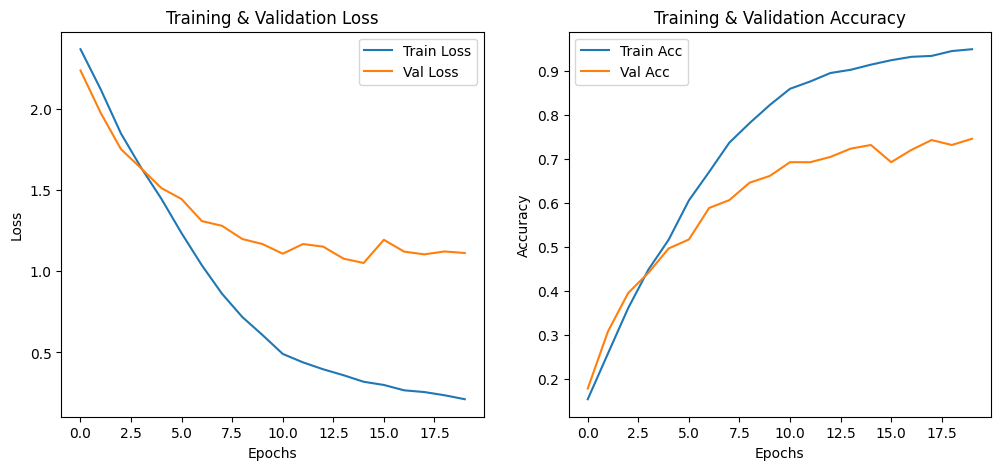

In [ ]:
custom_model = CustomCNN(num_classes=8).to(device)
custom_model, history = train_model(custom_model, train_loader, val_loader, device, num_epochs=20, lr=0.001)
plot_history(history)

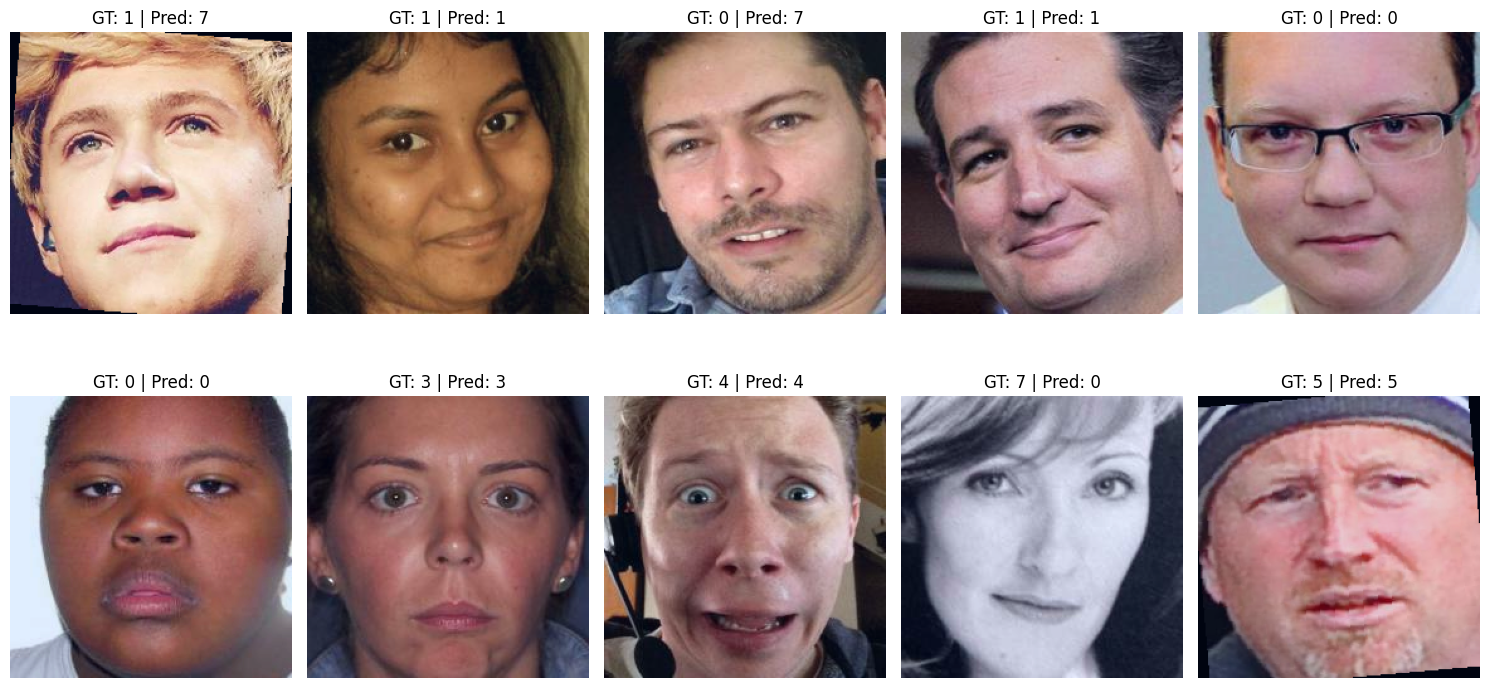

In [ ]:
def show_random_predictions(model, dataset, device, num_images=10):
    model.eval()
    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(indices):
        img, label, va = dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)  # add batch dim

        with torch.no_grad():
            exp_out, va_out = model(img_tensor)
            pred_label = torch.argmax(exp_out, dim=1).item()

        # convert back to numpy for display
        img_disp = img.permute(1, 2, 0).cpu().numpy()
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())  # normalize to [0,1]

        plt.subplot(2, 5, i+1)
        plt.imshow(img_disp)
        plt.axis("off")
        plt.title(f"GT: {label} | Pred: {pred_label}")

    plt.tight_layout()
    plt.show()


# Call the function
show_random_predictions(custom_model, val_dataset, device, num_images=10)


In [ ]:
# same transforms used for base_transform
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def predict_single_image(model, image_path, device, transform=inference_transform):
    # load image
    image = Image.open(image_path).convert("RGB")

    # apply transforms
    tensor = transform(image).unsqueeze(0).to(device)  # add batch dim

    # forward pass
    model.eval()
    with torch.no_grad():
        outputs_class, outputs_reg = model(tensor)

        # classification: get predicted label
        _, pred_class = torch.max(outputs_class, 1)

        # regression: raw valence/arousal values
        pred_reg = outputs_reg.squeeze().cpu().numpy()

    return pred_class.item(), pred_reg

image_path = "/content/Dataset/Dataset/images/137.jpg"
pred_class, pred_reg = predict_single_image(model, image_path, device)

print(f"Predicted Expression Class: {pred_class}")
print(f"Predicted Valence & Arousal: {pred_reg}")
class_map = {0: "Neutral", 1: "Happy", 2: "Sad", 3: "Angry", 4: "Surprise", 5: "Fear", 6: "Disgust", 7: "Contempt"}
print(f"Predicted Emotion: {class_map[pred_class]}")

Predicted Expression Class: 6
Predicted Valence & Arousal: [-0.57253915  0.5255987 ]
Predicted Emotion: Disgust
